# Heuristic Test: 3 gNodeBs, New Scheduler, 150 PRBs, Equal Slice Budget

This notebook tests the lower heuristic with the newer slice-aware scheduler on a 3-gNodeB topology.

Configuration:
- 3 gNodeBs in a triangle topology.
- Each gNodeB has `150` total PRBs.
- The PRB budget is divided equally across the 3 slices: `50 eMBB`, `50 URLLC`, `50 mMTC`.
- The test compares a neutral bias against a fixed heuristic bias derived from the overloaded/light target loads.

Rows are gNodeBs `0, 1, 2`; columns are slices `eMBB, URLLC, mMTC`.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from global_ppo_3gnb_env import GLOBAL_SNAPSHOT_SCENARIOS, GlobalPPO3GNBEnv, SLICE_TYPES

plt.rcParams.update({"figure.dpi": 125, "axes.grid": True, "grid.alpha": 0.22})
np.set_printoptions(precision=3, suppress=True)

GNB_IDS = (0, 1, 2)
GNB_NAMES = [f"gNB {g}" for g in GNB_IDS]

## Scenario Setup

In [2]:
SEED = 23
SCENARIO_NAME = "multi_slice_multi_gnb_congestion"
N_WINDOWS = 5
LOCAL_STEPS_PER_GLOBAL = 8
MAX_HANDOVERS_PER_LOCAL_STEP = 2

TOTAL_PRBS_PER_GNB = 150
SLICE_PRB_BUDGETS = {"eMBB": 50, "URLLC": 50, "mMTC": 50}

GNB_CONFIGS_3_150 = [
    {"id": 0, "x": 0.0, "y": 0.0, "coverage_radius": 560.0, "carrier_id": 0, "n_prbs": TOTAL_PRBS_PER_GNB},
    {"id": 1, "x": 430.0, "y": 0.0, "coverage_radius": 560.0, "carrier_id": 0, "n_prbs": TOTAL_PRBS_PER_GNB},
    {"id": 2, "x": 215.0, "y": 372.0, "coverage_radius": 560.0, "carrier_id": 0, "n_prbs": TOTAL_PRBS_PER_GNB},
]

TARGET_LOAD_MATRIX = GLOBAL_SNAPSHOT_SCENARIOS[SCENARIO_NAME].copy()

BIAS_FROM_TARGET = np.where(
    TARGET_LOAD_MATRIX >= 0.80,
    -0.75,      # overloaded source: encourage offload
    np.where(TARGET_LOAD_MATRIX <= 0.35, 0.55, 0.0),  # light source: retain users
).astype(float)

BIAS_TESTS = {
    "neutral_zero": np.zeros((3, 3), dtype=float),
    "heuristic_bias_from_target": BIAS_FROM_TARGET,
}

display(pd.DataFrame(TARGET_LOAD_MATRIX, index=GNB_NAMES, columns=SLICE_TYPES).style.set_caption("Snapshot target loads"))
display(pd.DataFrame(BIAS_FROM_TARGET, index=GNB_NAMES, columns=SLICE_TYPES).style.set_caption("Fixed bias used by the heuristic test"))

,eMBB,URLLC,mMTC
gNB 0,0.920000,0.860000,0.350000
gNB 1,0.320000,0.900000,0.880000
gNB 2,0.760000,0.300000,0.280000


,eMBB,URLLC,mMTC
gNB 0,-0.750000,-0.750000,0.550000
gNB 1,0.550000,-0.750000,-0.750000
gNB 2,0.000000,0.550000,0.550000


## Helpers

In [3]:
def apply_equal_slice_budget(env):
    env.base_env.slice_prb_budgets = env.base_env._normalize_slice_prb_budgets(SLICE_PRB_BUDGETS)
    env.base_env._apply_slice_prb_budgets()
    env.base_env._invalidate_metric_caches()


def make_env(seed=SEED):
    env = GlobalPPO3GNBEnv(
        seed=seed,
        n_gnbs=3,
        include_ue_counts=True,
        use_sumo_mobility=False,
        local_steps_per_global=LOCAL_STEPS_PER_GLOBAL,
        global_steps_per_episode=N_WINDOWS,
        radio_substeps=1,
        gnb_configs=GNB_CONFIGS_3_150,
        scenario_mode="snapshot",
        snapshot_scenario=SCENARIO_NAME,
        terminal_reward_only=False,
        use_progress_reward=False,
        max_handovers_per_local_step=MAX_HANDOVERS_PER_LOCAL_STEP,
    )
    apply_equal_slice_budget(env)
    return env


def matrix_df(matrix):
    return pd.DataFrame(np.asarray(matrix, dtype=float), index=GNB_NAMES, columns=SLICE_TYPES)


def load_matrix(env):
    return np.asarray(env._load_matrix(), dtype=float)


def ue_count_matrix(env):
    return np.asarray(
        [[env.base_env.get_slice_ue_count(gnb_id, slice_type) for slice_type in SLICE_TYPES] for gnb_id in GNB_IDS],
        dtype=int,
    )


def kpi_frame(env):
    rows = []
    for (gnb_id, slice_type), kpi in sorted(env.base_env._last_info.get("slice_kpis", {}).items()):
        row = {"gnb_id": gnb_id, "slice_type": slice_type}
        row.update(kpi)
        rows.append(row)
    return pd.DataFrame(rows)


def preview_offsets(env, bias_matrix):
    ue_counts = env._ue_count_dict()
    slice_loads = env._slice_load_dict()
    kmax = env._kmax_by_slice()
    rows = []
    saved_offsets = {gnb_id: dict(agent.previous_offsets) for gnb_id, agent in env.lower_agents.items()}
    for gnb_id, agent in env.lower_agents.items():
        bias_row = {slice_type: float(bias_matrix[gnb_id, s_idx]) for s_idx, slice_type in enumerate(SLICE_TYPES)}
        offsets = agent.compute_offsets(
            bias_row=bias_row,
            ue_counts=ue_counts,
            kmax=kmax,
            slice_loads=slice_loads,
            handover_failure_ratios={},
            ping_pong_ratios={},
        )
        agent.previous_offsets = saved_offsets[gnb_id]
        for (source, target, slice_type), info in offsets.items():
            rows.append({
                "source_gnb": source,
                "target_gnb": target,
                "slice_type": slice_type,
                "bias": info["bias"],
                "applied_offset_db": info["applied_offset_db"],
                "safety_term_db": info["safety_term_db"],
                "source_load": info["source_load"],
                "neighbor_load": info["neighbor_load"],
            })
    return pd.DataFrame(rows)


def heatmap(ax, matrix, title, cmap="viridis", vmin=0.0, vmax=1.0, fmt=".2f"):
    matrix = np.asarray(matrix, dtype=float)
    im = ax.imshow(matrix, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(SLICE_TYPES)), SLICE_TYPES)
    ax.set_yticks(range(len(GNB_IDS)), GNB_NAMES)
    ax.set_title(title)
    for r in range(matrix.shape[0]):
        for c in range(matrix.shape[1]):
            ax.text(c, r, format(matrix[r, c], fmt), ha="center", va="center", color="white", fontsize=9)
    return im

## Check Topology And Slice Budgets

In [4]:
env = make_env(SEED)
obs, info = env.reset(seed=SEED)
apply_equal_slice_budget(env)

topology = pd.DataFrame(
    [
        {
            "gnb_id": int(gnb.id),
            "x": float(gnb.x),
            "y": float(gnb.y),
            "coverage_radius": float(gnb.coverage_radius),
            "total_prbs": int(gnb.n_prbs),
            "eMBB_budget": env.base_env.get_slice_prb_budget(int(gnb.id), "eMBB"),
            "URLLC_budget": env.base_env.get_slice_prb_budget(int(gnb.id), "URLLC"),
            "mMTC_budget": env.base_env.get_slice_prb_budget(int(gnb.id), "mMTC"),
        }
        for gnb in env.base_env.gnbs
    ]
)
display(topology)

assert topology["total_prbs"].eq(150).all(), "Each gNodeB should have 150 PRBs"
assert topology[["eMBB_budget", "URLLC_budget", "mMTC_budget"]].eq(50).all().all(), "Each slice budget should be 50 PRBs"

env.close()

,gnb_id,x,y,coverage_radius,total_prbs,eMBB_budget,URLLC_budget,mMTC_budget
0,0,0.0,0.0,560.0,150,50,50,50
1,1,430.0,0.0,560.0,150,50,50,50
2,2,215.0,372.0,560.0,150,50,50,50


## Run Neutral And Heuristic Bias Tests

In [5]:
def run_fixed_bias(name, bias_matrix, seed=SEED):
    env = make_env(seed)
    obs, info = env.reset(seed=seed)
    apply_equal_slice_budget(env)

    before_load = load_matrix(env)
    before_counts = ue_count_matrix(env)
    offset_preview = preview_offsets(env, bias_matrix)

    rows = []
    total_handovers = 0
    last_info = info
    for window in range(N_WINDOWS):
        obs, reward, terminated, truncated, last_info = env.step(bias_matrix.reshape(-1))
        total_handovers += int(last_info["handover_count"])
        rows.append({
            "test": name,
            "window": window,
            "reward": float(reward),
            "handover_count": int(last_info["handover_count"]),
            "target_load_error": float(last_info["target_load_error"]),
            "load_variance": float(last_info["load_variance"]),
            "sla_count": float(last_info["sla_count"]),
        })
        if terminated or truncated:
            break

    after_load = load_matrix(env)
    after_counts = ue_count_matrix(env)
    kpis = kpi_frame(env)

    assert not kpis.empty, "No slice KPIs were produced"
    assert (kpis["used_prbs"] <= kpis["budget_prbs"]).all(), "A slice used more PRBs than its budget"
    assert set(kpis["budget_prbs"]) == {50}, "The equal 50 PRB slice budget was not preserved"

    env.close()
    return {
        "name": name,
        "bias_matrix": np.asarray(bias_matrix, dtype=float),
        "before_load": before_load,
        "after_load": after_load,
        "before_counts": before_counts,
        "after_counts": after_counts,
        "offset_preview": offset_preview,
        "trace": pd.DataFrame(rows),
        "kpis": kpis,
        "total_handovers": total_handovers,
        "final_info": last_info,
    }


results = {name: run_fixed_bias(name, matrix) for name, matrix in BIAS_TESTS.items()}

summary = []
for name, result in results.items():
    final = result["trace"].iloc[-1]
    summary.append({
        "test": name,
        "total_handovers": result["total_handovers"],
        "final_target_load_error": final["target_load_error"],
        "final_load_variance": final["load_variance"],
        "mean_reward": result["trace"]["reward"].mean(),
    })

display(pd.DataFrame(summary).sort_values("final_target_load_error"))

,test,total_handovers,final_target_load_error,final_load_variance,mean_reward
1,heuristic_bias_from_target,44,0.082507,0.138667,-7.220762
0,neutral_zero,4,0.131367,0.279111,-6.481838


## What Happened

In [6]:
for name, result in results.items():
    print("\n===", name, "===")
    print("Total handovers:", result["total_handovers"])
    print("Load before:")
    display(matrix_df(result["before_load"]))
    print("Load after:")
    display(matrix_df(result["after_load"]))
    print("UE counts before:")
    display(matrix_df(result["before_counts"]))
    print("UE counts after:")
    display(matrix_df(result["after_counts"]))
    print("Final slice KPIs:")
    display(result["kpis"].sort_values(["gnb_id", "slice_type"]))


=== neutral_zero ===
Total handovers: 4
Load before:


,eMBB,URLLC,mMTC
gNB 0,0.92,0.86,0.36
gNB 1,0.32,0.90,0.88
gNB 2,0.76,0.30,0.28


Load after:


,eMBB,URLLC,mMTC
gNB 0,1.00,0.2,1.00
gNB 1,0.32,1.0,1.00
gNB 2,1.00,0.6,0.44


UE counts before:


...

,eMBB,URLLC,mMTC
gNB 0,3.0,3.0,1.0
gNB 1,1.0,3.0,3.0
gNB 2,2.0,1.0,1.0


UE counts after:


,eMBB,URLLC,mMTC
gNB 0,1.0,1.0,2.0
gNB 1,2.0,4.0,1.0
gNB 2,3.0,2.0,2.0


Final slice KPIs:


,gnb_id,slice_type,used_prbs,budget_prbs,load,ue_count,throughput_bps,delay_s,dropped_bits
0,0,URLLC,18,50,0.36,1,1.105968e+06,0.000000,0.0
1,0,eMBB,28,50,0.56,1,2.872610e+06,0.000000,0.0
2,0,mMTC,34,50,0.68,2,8.194405e+06,0.000000,0.0
3,1,URLLC,50,50,1.00,4,9.229176e+05,0.023500,0.0
4,1,eMBB,50,50,1.00,2,6.036057e+04,0.038500,0.0
5,1,mMTC,32,50,0.64,1,1.501873e+06,0.000000,0.0
6,2,URLLC,30,50,0.60,2,6.847781e+06,0.000000,0.0
7,2,eMBB,50,50,1.00,3,9.186076e+06,0.010333,0.0
8,2,mMTC,50,50,1.00,2,1.913368e+06,0.023000,0.0


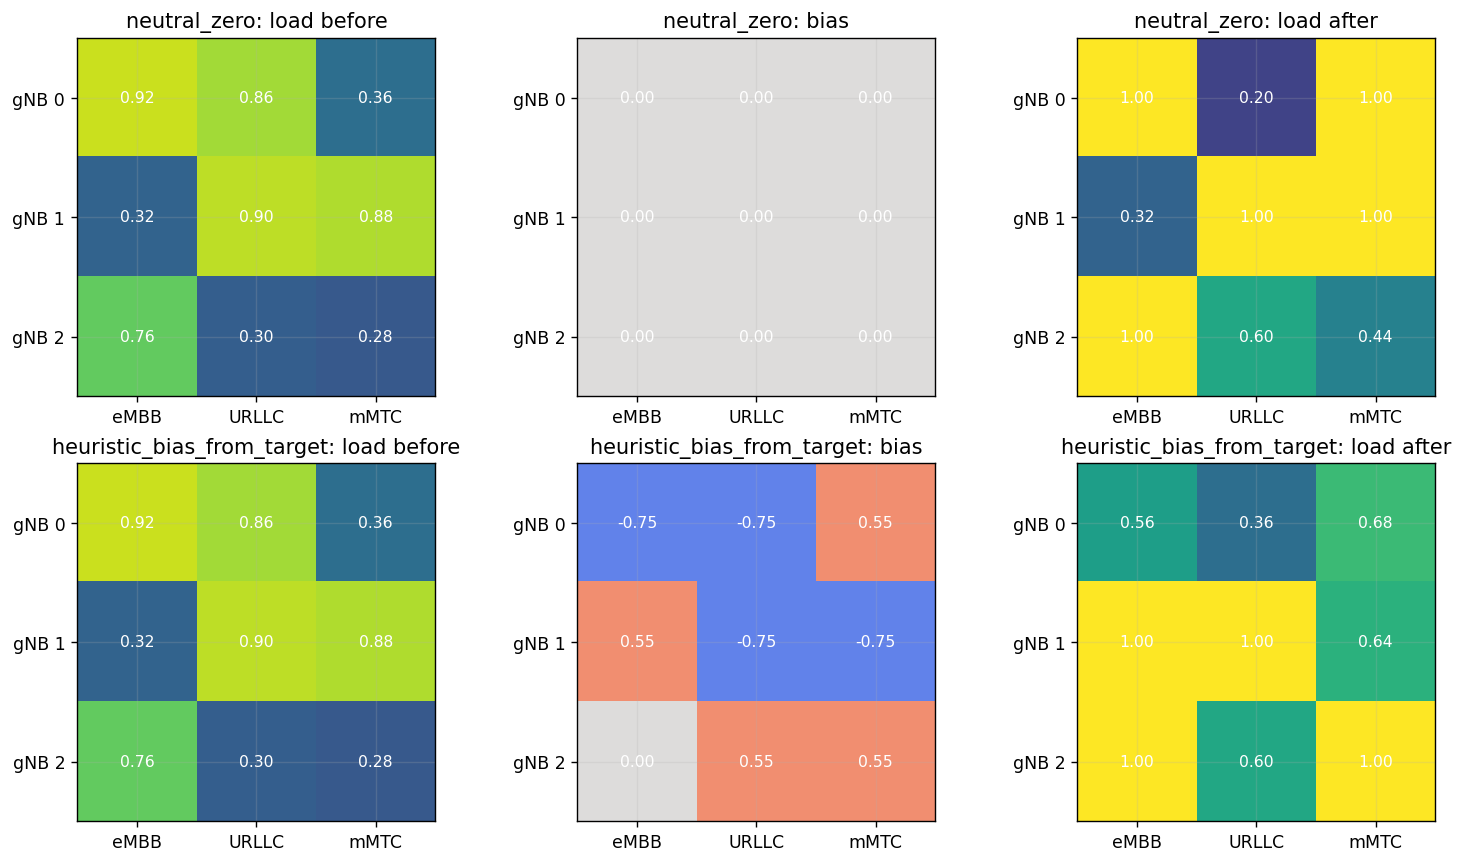

In [7]:
fig, axes = plt.subplots(len(results), 3, figsize=(12, 3.4 * len(results)), constrained_layout=True)
if len(results) == 1:
    axes = np.asarray([axes])

for row_idx, (name, result) in enumerate(results.items()):
    heatmap(axes[row_idx, 0], result["before_load"], f"{name}: load before")
    heatmap(axes[row_idx, 1], result["bias_matrix"], f"{name}: bias", cmap="coolwarm", vmin=-1.0, vmax=1.0, fmt=".2f")
    heatmap(axes[row_idx, 2], result["after_load"], f"{name}: load after")

plt.show()

## Initial Offset Preview

In [8]:
for name, result in results.items():
    print("\n===", name, "initial offsets ===")
    display(result["offset_preview"].sort_values(["source_gnb", "slice_type", "target_gnb"]))


=== neutral_zero initial offsets ===


,source_gnb,target_gnb,slice_type,bias,applied_offset_db,safety_term_db,source_load,neighbor_load
2,0,1,URLLC,0.0,2.0,3.600000,0.86,0.90
3,0,2,URLLC,0.0,0.0,0.000000,0.86,0.30
0,0,1,eMBB,0.0,0.0,0.000000,0.92,0.32
1,0,2,eMBB,0.0,2.0,1.813333,0.92,0.76
4,0,1,mMTC,0.0,2.0,3.440000,0.36,0.88
5,0,2,mMTC,0.0,0.0,0.000000,0.36,0.28
8,1,0,URLLC,0.0,2.0,3.280000,0.90,0.86
9,1,2,URLLC,0.0,0.0,0.000000,0.90,0.30
6,1,0,eMBB,0.0,2.0,3.760000,0.32,0.92
7,1,2,eMBB,0.0,2.0,1.813333,0.32,0.76



=== heuristic_bias_from_target initial offsets ===


,source_gnb,target_gnb,slice_type,bias,applied_offset_db,safety_term_db,source_load,neighbor_load
2,0,1,URLLC,-0.75,0.0,3.600000,0.86,0.90
3,0,2,URLLC,-0.75,-4.0,0.000000,0.86,0.30
0,0,1,eMBB,-0.75,-4.0,0.000000,0.92,0.32
1,0,2,eMBB,-0.75,0.0,1.813333,0.92,0.76
4,0,1,mMTC,0.55,6.0,3.440000,0.36,0.88
5,0,2,mMTC,0.55,2.0,0.000000,0.36,0.28
8,1,0,URLLC,-0.75,0.0,3.280000,0.90,0.86
9,1,2,URLLC,-0.75,-4.0,0.000000,0.90,0.30
6,1,0,eMBB,0.55,6.0,3.760000,0.32,0.92
7,1,2,eMBB,0.55,4.0,1.813333,0.32,0.76
